<a href="https://colab.research.google.com/github/sdkf7gkqf2-boop/portafolio/blob/main/imagesAI_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SafetyAI - Detección de objetos en carretera
Ejecuta las celdas en orden. En la celda 3 se te pedirá subir una imagen.

In [10]:
!pip install ImageAI
!wget -nc https://github.com/OlafenwaMoses/ImageAI/releases/download/3.0.0-pretrained/yolov3.pt

File ‘yolov3.pt’ already there; not retrieving.



In [11]:
import os
import cv2
from google.colab import files
from google.colab.patches import cv2_imshow
from imageai.Detection import ObjectDetection

MODEL_PATH = "/content/yolov3.pt"
OUTPUT_IMAGE = "/content/output_image.jpg"
VEHICULOS = {"car", "bus", "truck", "motorcycle", "bicycle"}

In [8]:
# Sube tu imagen (jpg, jpeg o png)
uploaded = files.upload()
INPUT_IMAGE = "/content/imput_image.jpeg" + list(uploaded.keys())[0]
print("Imagen cargada:", INPUT_IMAGE)

Saving imput_image.jpeg to imput_image (2).jpeg
Imagen cargada: /content/imput_image.jpegimput_image (2).jpeg


In [9]:
def detect_objects_on_road(input_image, output_image, model_path):
    """Detecta objetos en una imagen de carretera y guarda la imagen anotada."""
    detector = ObjectDetection()
    detector.setModelTypeAsYOLOv3()
    detector.setModelPath(model_path)
    detector.loadModel()

    detections = detector.detectObjectsFromImage(
        input_image=input_image,
        output_image_path=output_image,
        minimum_percentage_probability=30,
    )
    return detections


def analyze_objects(detections):
    """Cuenta los objetos detectados y muestra avisos de seguridad vial."""
    conteo = {}
    for obj in detections:
        conteo[obj["name"]] = conteo.get(obj["name"], 0) + 1

    print("\nResumen de objetos detectados:")
    if not conteo:
        print("  No se detectó ningún objeto.")
        return conteo
    for nombre, cantidad in conteo.items():
        print(f"  - {nombre}: {cantidad}")

    personas = conteo.get("person", 0)
    vehiculos = sum(n for nombre, n in conteo.items() if nombre in VEHICULOS)

    print("\nAnálisis de seguridad:")
    if personas and vehiculos:
        print("  ⚠️ Hay peatones y vehículos en la escena: extrema la precaución.")
    elif vehiculos:
        print("  🚗 Hay vehículos en la escena: no cruces sin mirar.")
    elif personas:
        print("  🚶 Solo se detectan peatones.")
    if "traffic light" in conteo:
        print("  🚦 Hay un semáforo: respétalo.")
    if "stop sign" in conteo:
        print("  🛑 Hay una señal de stop: detente por completo.")
    return conteo


def road_safety_rules():
    print()
    print("Hola, soy SafetyAI, una aplicación de seguridad vial.")
    print("Las normas de seguridad vial son muy importantes, y yo te ayudaré a recordarlas.")
    print("Recuerde: ¡es muy importante respetar las normas de seguridad vial y ser precavido al acercarse a la carretera!")
    print("Utiliza los semáforos y los pasos de peatones.")
    print("Nunca cruces una carretera por lugares que no estén diseñados para ello.")
    print("Recuerde que, al cruzar una carretera, debe ser igualmente prudente y previsible.")
    print("Tenga cuidado en la carretera y ¡buena suerte!")

In [16]:
# Corregimos la ruta obteniendo el nombre real del archivo subido
nombre_archivo = list(uploaded.keys())[0]
INPUT_IMAGE = f"/content/{nombre_archivo}"

detections = detect_objects_on_road(INPUT_IMAGE, OUTPUT_IMAGE, MODEL_PATH)

for each_object in detections:
    print(each_object["name"], " : ", each_object["percentage_probability"],
          " : ", each_object["box_points"])
    print("--------------------------------")

car  :  96.08  :  [225, 134, 261, 169]
--------------------------------
car  :  99.89  :  [119, 206, 182, 251]
--------------------------------
car  :  97.65  :  [165, 164, 213, 206]
--------------------------------
car  :  97.58  :  [189, 145, 236, 182]
--------------------------------
car  :  99.36  :  [284, 160, 330, 192]
--------------------------------
car  :  95.48  :  [0, 199, 33, 277]
--------------------------------
car  :  96.52  :  [352, 239, 417, 287]
--------------------------------
car  :  86.78  :  [225, 109, 271, 143]
--------------------------------
car  :  99.32  :  [131, 136, 167, 167]
--------------------------------
car  :  98.47  :  [289, 132, 330, 161]
--------------------------------
car  :  96.43  :  [28, 96, 65, 120]
--------------------------------
car  :  99.72  :  [327, 76, 355, 97]
--------------------------------
car  :  98.58  :  [53, 68, 74, 92]
--------------------------------
car  :  94.61  :  [117, 60, 143, 82]
--------------------------------
car  :

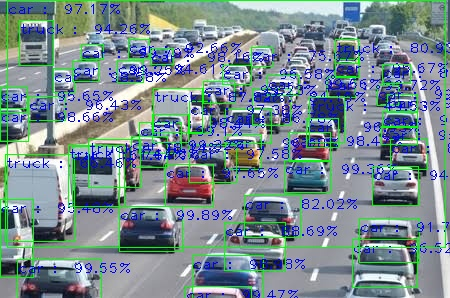

In [13]:
img = cv2.imread(OUTPUT_IMAGE, cv2.IMREAD_UNCHANGED)
cv2_imshow(img)

In [14]:
analyze_objects(detections)
road_safety_rules()


Resumen de objetos detectados:
  - car: 45
  - truck: 7

Análisis de seguridad:
  🚗 Hay vehículos en la escena: no cruces sin mirar.

Hola, soy SafetyAI, una aplicación de seguridad vial.
Las normas de seguridad vial son muy importantes, y yo te ayudaré a recordarlas.
Recuerde: ¡es muy importante respetar las normas de seguridad vial y ser precavido al acercarse a la carretera!
Utiliza los semáforos y los pasos de peatones.
Nunca cruces una carretera por lugares que no estén diseñados para ello.
Recuerde que, al cruzar una carretera, debe ser igualmente prudente y previsible.
Tenga cuidado en la carretera y ¡buena suerte!
